# Non-local GNN for Jet Classification

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.neighbors import KDTree
from sklearn.metrics import roc_auc_score, roc_curve, accuracy_score
import warnings
warnings.filterwarnings('ignore')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'VRAM   : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'PyTorch: {torch.__version__}')

Device : cuda
GPU    : Tesla P100-PCIE-16GB
VRAM   : 17.1 GB
PyTorch: 2.9.0+cu126


In [2]:
HDF5_PATH    = '/kaggle/input/datasets/siddharthjaiswal23/dataset-non-local-gnn/quark-gluon_data-set_n139306.hdf5'
N_SAMPLES    = 30000
K_NEIGHBOURS = 16
MIN_POINTS   = 5
THRESHOLD    = 1e-5
MAX_NODES    = 200 
N_HEADS      = 4
HIDDEN_DIM   = 64
LATENT_DIM   = 256
BATCH_SIZE   = 32
LR           = 1e-3
EPOCHS       = 40
TRAIN_R      = 0.75
VAL_R        = 0.15
SAVE_BASE    = 'best_baseline.pth'
SAVE_NL      = 'best_nonlocal.pth'
SEED         = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print('Config set.')

Config set.


In [3]:
def load_raw(filepath, n_samples=30000, seed=42):
    rng = np.random.default_rng(seed)
    with h5py.File(filepath, 'r') as f:
        total  = f['X_jets'].shape[0]
        n      = min(n_samples, total)
        chosen = np.sort(rng.choice(total, size=n, replace=False))
        print(f'Loading {n:,} / {total:,} samples ')
        Xp, yp = [], []
        for start in range(0, n, 5000):
            b = chosen[start:start+5000].tolist()
            Xp.append(f['X_jets'][b])
            yp.append(f['y'][b])
            print(f'  {min(start+5000, n):,}/{n:,}', end='\r')
    X = np.concatenate(Xp).astype(np.float32).transpose(0, 3, 1, 2) 
    y = np.concatenate(yp).astype(np.int64)
    print(f'\nX: {X.shape}  |  Gluon: {(y==0).sum():,}  Quark: {(y==1).sum():,}')
    return X, y
X_raw, y_all = load_raw(HDF5_PATH, N_SAMPLES, SEED)

Loading 30,000 / 139,306 samples 
  30,000/30,000
X: (30000, 3, 125, 125)  |  Gluon: 15,168  Quark: 14,832


In [4]:
def image_to_pointcloud(img, threshold=1e-5):
    mask       = np.any(img > threshold, axis=0) 
    rows, cols = np.where(mask)
    if len(rows) < MIN_POINTS:
        return None

    eta = rows / 124.0   
    phi = cols / 124.0   
    def norm(v):
        v = np.log1p(v)
        m = v.max()
        return v / m if m > 0 else v
    ecal  = norm(img[0, rows, cols])
    hcal  = norm(img[1, rows, cols])
    track = norm(img[2, rows, cols])
    return np.stack([eta, phi, ecal, hcal, track], axis=1).astype(np.float32)
def build_knn_edges(pts, k=16):
    pos  = pts[:, :2]          
    k    = min(k, len(pts) - 1)
    _, idx = KDTree(pos).query(pos, k=k+1)
    idx  = idx[:, 1:]          
    n    = len(pts)
    src  = idx.flatten()
    dst  = np.repeat(np.arange(n), k)
    # make undirected
    both = np.unique(
        np.stack([np.concatenate([src, dst]),
                  np.concatenate([dst, src])], axis=1), axis=0)
    return both[:, 0].astype(np.int64), both[:, 1].astype(np.int64)
def build_all_graphs(X, y, k=16):
    graphs, skipped = [], 0
    for i in range(len(X)):
        if i % 5000 == 0:
            print(f'  {i:,}/{len(X):,}', end='\r')
        pts = image_to_pointcloud(X[i])
        if pts is None:
            skipped += 1
            continue
        src, dst = build_knn_edges(pts, k)
        graphs.append({
            'x'  : torch.tensor(pts,       dtype=torch.float32),
            'src': torch.tensor(src,       dtype=torch.long),
            'dst': torch.tensor(dst,       dtype=torch.long),
            'y'  : torch.tensor(int(y[i]), dtype=torch.long),
        })
    print(f'\nGraphs: {len(graphs):,}   Skipped: {skipped}')
    g = graphs[0]
    print(f'Sample — nodes: {g["x"].shape[0]}  edges: {g["src"].shape[0]}')
    return graphs
all_graphs = build_all_graphs(X_raw, y_all, K_NEIGHBOURS)
import gc; del X_raw; gc.collect()

  25,000/30,000
Graphs: 30,000   Skipped: 0
Sample — nodes: 884  edges: 17480


0

In [5]:
class GraphDataset(Dataset):
    def __init__(self, graphs): self.graphs = graphs
    def __len__(self): return len(self.graphs)
    def __getitem__(self, idx): return self.graphs[idx]
def collate_graphs(batch):
    x_list, src_list, dst_list, batch_list, y_list = [], [], [], [], []
    sizes = []
    offset = 0
    for i, g in enumerate(batch):
        n = g['x'].shape[0]
        x_list.append(g['x'])
        src_list.append(g['src'] + offset)
        dst_list.append(g['dst'] + offset)
        batch_list.append(torch.full((n,), i, dtype=torch.long))
        y_list.append(g['y'])
        sizes.append(n)
        offset += n
    return {
        'x'    : torch.cat(x_list),
        'src'  : torch.cat(src_list),
        'dst'  : torch.cat(dst_list),
        'batch': torch.cat(batch_list),
        'y'    : torch.stack(y_list),
        'sizes': torch.tensor(sizes, dtype=torch.long),  # (B,)
    }
def make_loaders(graphs, train_r=0.75, val_r=0.15, batch_size=32, seed=42):
    rng     = np.random.default_rng(seed)
    idx     = rng.permutation(len(graphs))
    n_train = int(len(graphs) * train_r)
    n_val   = int(len(graphs) * val_r)
    train   = [graphs[i] for i in idx[:n_train]]
    val     = [graphs[i] for i in idx[n_train:n_train+n_val]]
    test    = [graphs[i] for i in idx[n_train+n_val:]]
    kw = dict(batch_size=batch_size, collate_fn=collate_graphs, num_workers=0)
    for name, s in [('train', train), ('val', val), ('test', test)]:
        nq = sum(g['y'].item() for g in s)
        print(f'{name:5s}: {len(s):,}  ({nq/len(s)*100:.1f}% quark)')
    return (DataLoader(GraphDataset(train), shuffle=True,  **kw),
            DataLoader(GraphDataset(val),   shuffle=False, **kw),
            DataLoader(GraphDataset(test),  shuffle=False, **kw))
train_loader, val_loader, test_loader = make_loaders(
    all_graphs, TRAIN_R, VAL_R, BATCH_SIZE, SEED)

train: 22,500  (49.7% quark)
val  : 4,500  (48.9% quark)
test : 3,000  (48.3% quark)


In [6]:
def scatter_mean(src_feat, dst_idx, num_nodes):
    F_dim = src_feat.shape[1]
    out   = torch.zeros(num_nodes, F_dim,
                        device=src_feat.device, dtype=src_feat.dtype)
    cnt   = torch.zeros(num_nodes,
                        device=src_feat.device, dtype=src_feat.dtype)
    out.index_add_(0, dst_idx, src_feat)
    cnt.index_add_(0, dst_idx,
                   torch.ones(len(dst_idx),
                              device=src_feat.device, dtype=src_feat.dtype))
    return out / cnt.unsqueeze(1).clamp(min=1)
def global_max_pool(x, batch, B):
    out = []
    for g in range(B):
        xg = x[batch == g]
        if xg.shape[0] > 0:
            out.append(xg.max(dim=0).values)
        else:
            out.append(torch.zeros(x.shape[1], device=x.device))
    return torch.stack(out)   
def global_mean_pool(x, batch, B):
    F_dim = x.shape[1]
    out   = torch.zeros(B, F_dim, device=x.device, dtype=x.dtype)
    cnt   = torch.zeros(B,        device=x.device, dtype=x.dtype)
    out.index_add_(0, batch, x)
    cnt.index_add_(0, batch,
                   torch.ones(x.shape[0], device=x.device, dtype=x.dtype))
    return out / cnt.unsqueeze(1).clamp(min=1)
def _test_grads():
    x   = torch.randn(10, 8, requires_grad=True)
    dst = torch.tensor([0,0,1,1,2,2,3,3,4,4])
    scatter_mean(x, dst, 5).sum().backward()
    assert x.grad is not None and not torch.isnan(x.grad).any(), 'scatter_mean BROKEN'
    print('  scatter_mean       gradient OK')
    x2  = torch.randn(9, 8, requires_grad=True)
    bat = torch.tensor([0,0,0,1,1,1,2,2,2])
    global_mean_pool(x2, bat, 3).sum().backward()
    assert x2.grad is not None, 'global_mean_pool BROKEN'
    print('  global_mean_pool   gradient OK')
    x3  = torch.randn(9, 8, requires_grad=True)
    bat3= torch.tensor([0,0,0,1,1,1,2,2,2])
    global_max_pool(x3, bat3, 3).sum().backward()
    assert x3.grad is not None, 'global_max_pool BROKEN'
    print('  global_max_pool    gradient OK')
_test_grads()

  scatter_mean       gradient OK
  global_mean_pool   gradient OK
  global_max_pool    gradient OK


In [7]:
class EdgeConvLayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(2 * in_dim, out_dim, bias=False),
            nn.BatchNorm1d(out_dim),
            nn.LeakyReLU(0.2),
            nn.Linear(out_dim, out_dim, bias=False),
            nn.BatchNorm1d(out_dim),
            nn.LeakyReLU(0.2),
        )
    def forward(self, x, src, dst):
        edge_feat = self.mlp(
            torch.cat([x[dst], x[src] - x[dst]], dim=1)
        )                          
        return scatter_mean(edge_feat, dst, x.shape[0])

In [8]:
class NonLocalBlock(nn.Module):
    def __init__(self, dim, n_heads=4, max_nodes=200, dropout=0.1):
        super().__init__()
        self.M     = max_nodes
        self.attn  = nn.MultiheadAttention(
            embed_dim   = dim,
            num_heads   = n_heads,
            dropout     = dropout,
            batch_first = True 
        )
        self.norm1 = nn.LayerNorm(dim)
        self.norm2 = nn.LayerNorm(dim)
        self.ff    = nn.Sequential(
            nn.Linear(dim, dim * 2), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim)
        )
    def forward(self, x, batch, sizes):
        B   = sizes.shape[0]
        dim = x.shape[1]
        M   = self.M
        dev = x.device
        x_pad    = torch.zeros(B, M, dim, device=dev, dtype=x.dtype)
        pad_mask = torch.ones (B, M,      device=dev, dtype=torch.bool)
        ptr = 0
        for g in range(B):
            n_g   = int(sizes[g].item())
            n_use = min(n_g, M)
            x_pad[g, :n_use]    = x[ptr : ptr + n_use]
            pad_mask[g, :n_use] = False  
            ptr += n_g
        attn_out, _ = self.attn(
            x_pad, x_pad, x_pad,
            key_padding_mask=pad_mask
        )  
        x_pad = self.norm1(x_pad + attn_out)
        x_pad = self.norm2(x_pad + self.ff(x_pad))
        parts = []
        ptr   = 0
        for g in range(B):
            n_g   = int(sizes[g].item())
            n_use = min(n_g, M)
            parts.append(x_pad[g, :n_use])
            if n_g > M:
                parts.append(x[ptr + M : ptr + n_g])
            ptr += n_g

        return torch.cat(parts, dim=0)   

print('Batched attention + padding mask')

Batched attention + padding mask


In [9]:
class DGCNNBaseline(nn.Module):
    def __init__(self, in_dim=5, hidden=64, latent=256, num_classes=2):
        super().__init__()
        self.conv1 = EdgeConvLayer(in_dim,    hidden)
        self.conv2 = EdgeConvLayer(hidden,    hidden * 2)
        self.conv3 = EdgeConvLayer(hidden*2,  latent)
        self.head  = nn.Sequential(
            nn.Linear(latent*2, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256,      128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, d):
        x   = d['x'].to(DEVICE)
        src = d['src'].to(DEVICE)
        dst = d['dst'].to(DEVICE)
        bat = d['batch'].to(DEVICE)
        B   = d['y'].shape[0]
        x   = self.conv1(x, src, dst)
        x   = self.conv2(x, src, dst)
        x   = self.conv3(x, src, dst)
        g   = torch.cat([global_max_pool(x, bat, B),
                         global_mean_pool(x, bat, B)], dim=1)  
        return self.head(g)
class NonLocalGNN(nn.Module):
    def __init__(self, in_dim=5, hidden=64, latent=256,
                 n_heads=4, max_nodes=200, num_classes=2):
        super().__init__()
        self.conv1    = EdgeConvLayer(in_dim,   hidden)
        self.conv2    = EdgeConvLayer(hidden,   hidden * 2)
        self.nonlocal_blk = NonLocalBlock(hidden * 2, n_heads, max_nodes)
        self.conv3    = EdgeConvLayer(hidden*2, latent)
        self.head     = nn.Sequential(
            nn.Linear(latent*2, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256,      128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
    def forward(self, d):
        x   = d['x'].to(DEVICE)
        src = d['src'].to(DEVICE)
        dst = d['dst'].to(DEVICE)
        bat = d['batch'].to(DEVICE)
        sz  = d['sizes'].to(DEVICE)   
        B   = d['y'].shape[0]
        x = self.conv1(x, src, dst)  
        x = self.conv2(x, src, dst)  
        x = self.nonlocal_blk(x, bat, sz)  
        x = self.conv3(x, src, dst)        
        g = torch.cat([global_max_pool(x, bat, B),
                       global_mean_pool(x, bat, B)], dim=1) 
        return self.head(g)
def count_params(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)
base_model = DGCNNBaseline(
    in_dim=5, hidden=HIDDEN_DIM, latent=LATENT_DIM).to(DEVICE)
nl_model = NonLocalGNN(
    in_dim=5, hidden=HIDDEN_DIM, latent=LATENT_DIM,
    n_heads=N_HEADS, max_nodes=MAX_NODES).to(DEVICE)
print(f'Baseline DGCNN  params : {count_params(base_model):,}')
print(f'Non-local GNN   params : {count_params(nl_model):,}')

Baseline DGCNN  params : 334,850
Non-local GNN   params : 467,330


In [10]:
def gradient_check(model, loader, name):
    model.train()
    batch  = next(iter(loader))
    logits = model(batch)
    loss   = nn.CrossEntropyLoss()(logits, batch['y'].to(DEVICE))
    loss.backward()
    ok_count, zero_count, none_count = 0, 0, 0
    for _, p in model.named_parameters():
        if p.requires_grad:
            if p.grad is None:
                none_count += 1
            elif p.grad.abs().max().item() < 1e-9:
                zero_count += 1
            else:
                ok_count += 1
    healthy = (ok_count > 0) and (none_count == 0)
    status  = 'OK -- safe to train' if healthy else 'BROKEN -- fix before training'
    print(f'{name}')
    print(f'  loss={loss.item():.4f}  '
          f'params_with_grad={ok_count}  '
          f'zero_grad={zero_count}  '
          f'none_grad={none_count}')
    print(f'  Status: {status}')
    model.zero_grad()
    return healthy
ok_base = gradient_check(base_model, train_loader, 'Baseline DGCNN')
print()
ok_nl   = gradient_check(nl_model,   train_loader, 'Non-local GNN')

Baseline DGCNN
  loss=0.7715  params_with_grad=24  zero_grad=0  none_grad=0
  Status: OK -- safe to train

Non-local GNN
  loss=0.8261  params_with_grad=36  zero_grad=0  none_grad=0
  Status: OK -- safe to train


In [11]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for batch in loader:
        y      = batch['y'].to(DEVICE)
        logits = model(batch)
        loss   = criterion(logits, y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * y.shape[0]
        correct    += (logits.argmax(1) == y).sum().item()
        total      += y.shape[0]
    return total_loss / total, correct / total
def evaluate(model, loader):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            y      = batch['y'].to(DEVICE)
            logits = model(batch)
            loss   = nn.CrossEntropyLoss()(logits, y)
            probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.cpu().numpy())
            total_loss += loss.item() * y.shape[0]
            correct    += (logits.argmax(1) == y).sum().item()
            total      += y.shape[0]
    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    return total_loss / total, correct / total, roc_auc_score(labels, probs)
def run_training(model, label, save_path,
                 lr=1e-3, epochs=40, patience=8):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=epochs, eta_min=1e-5)
    history  = {'train_loss': [], 'val_loss': [], 'val_auc': [], 'val_acc': []}
    best_auc, wait = 0.0, 0
    print(f'\n Training: {label} ')
    print(f'  {"Ep":>4}  {"TrLoss":>8}  {"VaLoss":>8}  {"VaAUC":>7}  {"VaAcc":>7}')

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc            = train_epoch(model, loader=train_loader,
                                                 criterion=criterion, optimizer=optimizer)
        val_loss, val_acc, val_auc = evaluate(model, val_loader)
        scheduler.step()
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(val_loss)
        history['val_auc'].append(val_auc)
        history['val_acc'].append(val_acc)
        note = ''
        if val_auc > best_auc:
            best_auc = val_auc
            torch.save(model.state_dict(), save_path)
            wait = 0
            note = ' best'
        else:
            wait += 1

        print(f'  {epoch:03d}/{epochs}  {tr_loss:8.4f}  {val_loss:8.4f}'
              f'  {val_auc:7.4f}  {val_acc*100:6.2f}%{note}')
        if wait >= patience:
            print(f'  Early stopping -- best val AUC: {best_auc:.4f}')
            break
    return history, best_auc
print('Training ready.')

Training ready.


In [12]:
base_history, base_best_auc = run_training(
    base_model, label='Baseline DGCNN', save_path=SAVE_BASE
)


 Training: Baseline DGCNN 
    Ep    TrLoss    VaLoss    VaAUC    VaAcc
  001/40    0.6577    0.6455   0.7286   64.73% best
  002/40    0.6180    0.6102   0.7469   68.40% best
  003/40    0.6072    0.6068   0.7462   68.02%
  004/40    0.5999    0.5872   0.7569   69.36% best
  005/40    0.5955    0.6166   0.7564   67.51%
  006/40    0.5904    0.5916   0.7625   69.09% best
  007/40    0.5878    0.5889   0.7634   70.49% best
  008/40    0.5887    0.5997   0.7632   70.20%
  009/40    0.5864    0.5822   0.7661   70.44% best
  010/40    0.5845    0.5945   0.7604   69.40%
  011/40    0.5827    0.5957   0.7662   70.04% best
  012/40    0.5815    0.6074   0.7674   68.71% best
  013/40    0.5788    0.5874   0.7658   69.49%
  014/40    0.5783    0.5865   0.7649   70.22%
  015/40    0.5786    0.5962   0.7686   68.89% best
  016/40    0.5750    0.5883   0.7688   70.33% best
  017/40    0.5744    0.5858   0.7688   70.69% best
  018/40    0.5718    0.5856   0.7668   70.51%
  019/40    0.5716    0.58

In [13]:
nl_history, nl_best_auc = run_training(
    nl_model, label='Non-local GNN', save_path=SAVE_NL
)


 Training: Non-local GNN 
    Ep    TrLoss    VaLoss    VaAUC    VaAcc
  001/40    0.6510    0.6081   0.7483   68.53% best
  002/40    0.6111    0.5975   0.7576   68.82% best
  003/40    0.6017    0.6044   0.7480   68.96%
  004/40    0.6020    0.6062   0.7604   68.00% best
  005/40    0.5973    0.5927   0.7618   69.78% best
  006/40    0.5930    0.5985   0.7536   68.22%
  007/40    0.5944    0.6061   0.7661   70.36% best
  008/40    0.5897    0.5944   0.7650   69.24%
  009/40    0.5867    0.6131   0.7615   68.22%
  010/40    0.5865    0.6121   0.7668   68.73% best
  011/40    0.5853    0.5886   0.7642   70.53%
  012/40    0.5825    0.5925   0.7689   70.42% best
  013/40    0.5811    0.6039   0.7672   70.56%
  014/40    0.5810    0.5865   0.7706   71.02% best
  015/40    0.5809    0.5921   0.7703   70.93%
  016/40    0.5783    0.5932   0.7691   70.22%
  017/40    0.5774    0.5895   0.7704   70.44%
  018/40    0.5753    0.5800   0.7706   70.98%
  019/40    0.5738    0.5840   0.7714   70

In [14]:
def get_test_results(model, loader, save_path):
    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    model.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            y      = batch['y'].to(DEVICE)
            logits = model(batch)
            probs  = F.softmax(logits, dim=1)[:, 1].cpu().numpy()
            all_probs.append(probs)
            all_labels.append(y.cpu().numpy())
    probs  = np.concatenate(all_probs)
    labels = np.concatenate(all_labels)
    auc    = roc_auc_score(labels, probs)
    acc    = accuracy_score(labels, probs > 0.5)
    fpr, tpr, _ = roc_curve(labels, probs)
    return auc, acc, fpr, tpr, probs, labels
b_auc, b_acc, b_fpr, b_tpr, b_probs, test_labels = \
    get_test_results(base_model, test_loader, SAVE_BASE)

n_auc, n_acc, n_fpr, n_tpr, n_probs, _ = \
    get_test_results(nl_model, test_loader, SAVE_NL)
delta = n_auc - b_auc
print('Final Test Results')
print(f'  {"":<24} {"Baseline DGCNN":>14}  {"Non-local GNN":>13}')
print(f'  {"Architecture":<24} {"3x EdgeConv":>14}  {"2xEC+NL+EC":>13}')
print(f'  {"Non-local component":<24} {"None":>14}  {"4-head Attn":>13}')
print(f'  {"Params":<24} {count_params(base_model):>14,}  {count_params(nl_model):>13,}')
print(f'  {"Test ROC-AUC":<24} {b_auc:>14.4f}  {n_auc:>13.4f}')
print(f'  {"Test Accuracy":<24} {b_acc*100:>13.2f}%  {n_acc*100:>12.2f}%')
print(f'  {"Delta AUC":<24} {"":>14}  {"+"+str(round(delta,4)) if delta>=0 else str(round(delta,4)):>13}')

Final Test Results
                           Baseline DGCNN  Non-local GNN
  Architecture                3x EdgeConv     2xEC+NL+EC
  Non-local component                None    4-head Attn
  Params                          334,850        467,330
  Test ROC-AUC                     0.7786         0.7819
  Test Accuracy                    69.93%         70.53%
  Delta AUC                                      +0.0033


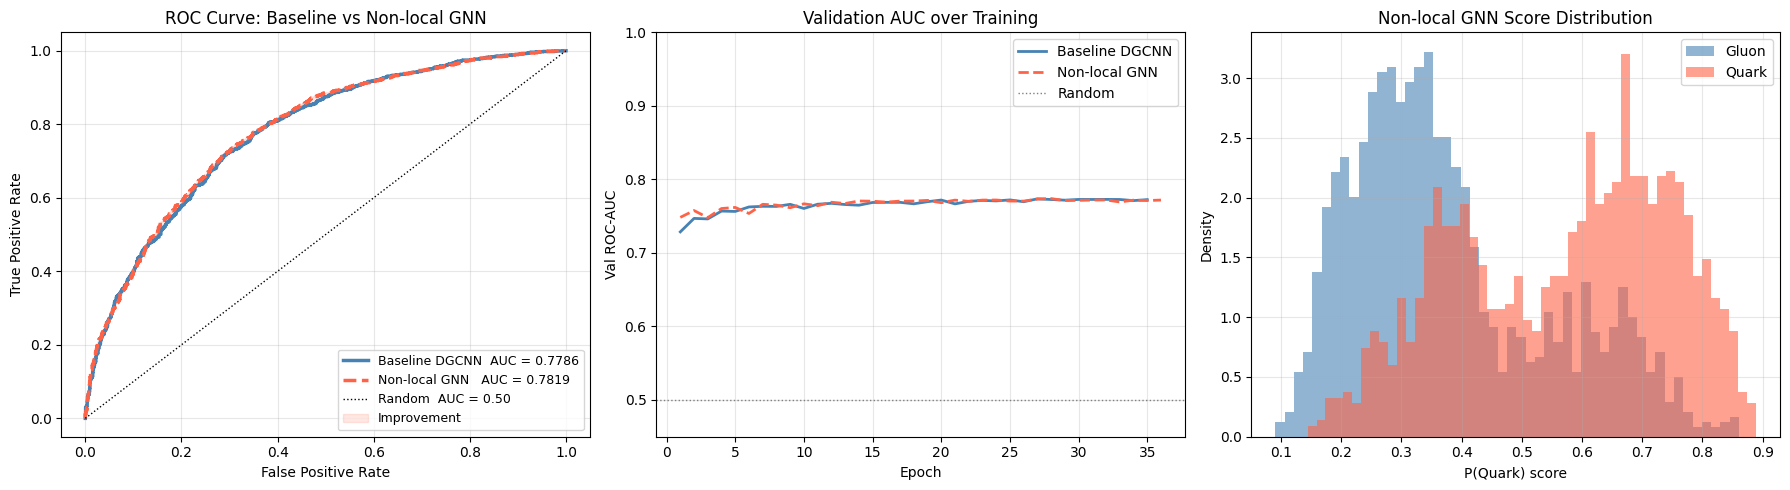

Saved: task4_results.png


In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(b_fpr, b_tpr, lw=2.5, color='steelblue',
             label=f'Baseline DGCNN  AUC = {b_auc:.4f}')
axes[0].plot(n_fpr, n_tpr, lw=2.5, color='tomato', linestyle='--',
             label=f'Non-local GNN   AUC = {n_auc:.4f}')
axes[0].plot([0, 1], [0, 1], 'k:', lw=1, label='Random  AUC = 0.50')
b_tpr_interp = np.interp(n_fpr, b_fpr, b_tpr)
axes[0].fill_between(n_fpr, b_tpr_interp, n_tpr,
                     where=(n_tpr > b_tpr_interp),
                     alpha=0.15, color='tomato', label='Improvement')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve: Baseline vs Non-local GNN')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)
ep_b = range(1, len(base_history['val_auc']) + 1)
ep_n = range(1, len(nl_history['val_auc'])   + 1)
axes[1].plot(ep_b, base_history['val_auc'], color='steelblue', lw=2,
             label='Baseline DGCNN')
axes[1].plot(ep_n, nl_history['val_auc'],   color='tomato',    lw=2,
             linestyle='--', label='Non-local GNN')
axes[1].axhline(0.5, color='grey', linestyle=':', lw=1, label='Random')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Val ROC-AUC')
axes[1].set_title('Validation AUC over Training')
axes[1].set_ylim(0.45, 1.0)
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[2].hist(n_probs[test_labels == 0], bins=50, alpha=0.6,
             density=True, label='Gluon', color='steelblue')
axes[2].hist(n_probs[test_labels == 1], bins=50, alpha=0.6,
             density=True, label='Quark', color='tomato')
axes[2].set_xlabel('P(Quark) score')
axes[2].set_ylabel('Density')
axes[2].set_title('Non-local GNN Score Distribution')
axes[2].legend()
axes[2].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('task4_results.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: task4_results.png')